In [ ]:
# re-run
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/CMPE_252/EN-BN-NMT-Project'
os.makedirs(PROJECT_DIR, exist_ok=True)
print("Project folder ready at:", PROJECT_DIR)

Mounted at /content/drive
Project folder ready at: /content/drive/MyDrive/CMPE_252/EN-BN-NMT-Project


In [ ]:
!pip install datasets sentencepiece sacrebleu transformers -q

import torch, re
from datasets import load_dataset

dataset = load_dataset("Helsinki-NLP/opus-100", "bn-en")

def is_clean(example):
    bn = example["translation"]["bn"]
    en = example["translation"]["en"]
    if re.search(r'\s্\s', bn):
        return False
    if len(bn.strip()) == 0 or len(en.strip()) == 0:
        return False
    return True

clean_train = dataset["train"].filter(is_clean)
train_subset = clean_train.shuffle(seed=7).select(range(100000))
print(f"Training on {len(train_subset)} clean examples")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.3 MB/s eta 0:00:00


README.md:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

bn-en/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  279kB            

bn-en/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

bn-en/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  134MB            

...

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Training on 100000 clean examples


In [ ]:
# --- Tokenizer TRAINING (already done — DO NOT RE-RUN) ---
# This is the original code that created spm_en.model / spm_bn.model, saved to Drive.
# Kept here as documentation of the tokenization process for the report.
# To use the tokenizers in a new session, see the LOADING cell instead (below or elsewhere).
import sentencepiece as spm

with open(f"{PROJECT_DIR}/train.en", "w", encoding="utf-8") as f_en, \
     open(f"{PROJECT_DIR}/train.bn", "w", encoding="utf-8") as f_bn:
    for ex in train_subset["translation"]:
        f_en.write(ex["en"].strip() + "\n")
        f_bn.write(ex["bn"].strip() + "\n")

spm.SentencePieceTrainer.train(
    input=f"{PROJECT_DIR}/train.en", model_prefix=f"{PROJECT_DIR}/spm_en",
    vocab_size=8000, character_coverage=1.0, model_type="bpe",
    pad_id=0, unk_id=1, bos_id=2, eos_id=3
)
spm.SentencePieceTrainer.train(
    input=f"{PROJECT_DIR}/train.bn", model_prefix=f"{PROJECT_DIR}/spm_bn",
    vocab_size=8000, character_coverage=1.0, model_type="bpe",
    pad_id=0, unk_id=1, bos_id=2, eos_id=3
)

sp_en = spm.SentencePieceProcessor(model_file=f"{PROJECT_DIR}/spm_en.model")
sp_bn = spm.SentencePieceProcessor(model_file=f"{PROJECT_DIR}/spm_bn.model")
print("Tokenizers trained and saved to Drive")

NameError: name 'PROJECT_DIR' is not defined

In [ ]:
# --- Sanity check: confirm expected files exist in Drive ---
import os
print(os.listdir(PROJECT_DIR))

['spm_bn.model', 'spm_bn.vocab', 'spm_en.model', 'spm_en.vocab', 'results_from_scratch.json', 'EN-BN-NMT-Project-Report.docx', 'checkpoint.pt', 'Untitled0.ipynb', 'old_EN_BN_NMT_Project.ipynb']


In [ ]:
# --- Tokenizer LOADING (run this in every new session) ---
import sentencepiece as spm
sp_en = spm.SentencePieceProcessor(model_file=f"{PROJECT_DIR}/spm_en.model")
sp_bn = spm.SentencePieceProcessor(model_file=f"{PROJECT_DIR}/spm_bn.model")
print("Tokenizers loaded from Drive")

Tokenizers loaded from Drive


In [ ]:
# --- Data pipeline for FROM-SCRATCH Transformer model ---
# Encodes (English, Bangla) pairs into token IDs, filters by MAX_LEN,
# and builds a padded DataLoader for training/reloading the from-scratch model.
# Requires sp_en/sp_bn to be loaded first (see tokenizer LOADING cell).

MAX_LEN = 80

def encode_pair(en_text, bn_text):
    en_ids = [2] + sp_en.encode(en_text, out_type=int) + [3]
    bn_ids = [2] + sp_bn.encode(bn_text, out_type=int) + [3]
    return en_ids, bn_ids

encoded_pairs = []
for ex in train_subset["translation"]:
    en_ids, bn_ids = encode_pair(ex["en"], ex["bn"])
    if len(en_ids) <= MAX_LEN and len(bn_ids) <= MAX_LEN:
        encoded_pairs.append((en_ids, bn_ids))

print(f"Kept {len(encoded_pairs)} out of {len(train_subset)} pairs")

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        en_ids, bn_ids = self.pairs[idx]
        return torch.tensor(en_ids), torch.tensor(bn_ids)

def collate_fn(batch):
    en_batch, bn_batch = zip(*batch)
    en_padded = pad_sequence(en_batch, batch_first=True, padding_value=0)
    bn_padded = pad_sequence(bn_batch, batch_first=True, padding_value=0)
    return en_padded, bn_padded

train_dataset = TranslationDataset(encoded_pairs)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
print(f"Batches per epoch: {len(train_loader)}")

Kept 99260 out of 100000 pairs
Batches per epoch: 3102


In [ ]:
# --- Model architecture for FROM-SCRATCH Transformer (FINAL VERSION) ---
# Creates a fresh, untrained model instance. Must load checkpoint.pt afterward
# to restore trained weights (see loading cell below).
import math

VOCAB_SIZE = 8000
PAD_IDX = 0
D_MODEL = 256
N_HEADS = 4
N_LAYERS = 3
FF_DIM = 512
DROPOUT = 0.1

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TranslationTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.src_embed = nn.Embedding(VOCAB_SIZE, D_MODEL, padding_idx=PAD_IDX)
        self.tgt_embed = nn.Embedding(VOCAB_SIZE, D_MODEL, padding_idx=PAD_IDX)
        self.pos_enc = PositionalEncoding(D_MODEL)
        self.transformer = nn.Transformer(
            d_model=D_MODEL, nhead=N_HEADS,
            num_encoder_layers=N_LAYERS, num_decoder_layers=N_LAYERS,
            dim_feedforward=FF_DIM, dropout=DROPOUT, batch_first=True
        )
        self.output_proj = nn.Linear(D_MODEL, VOCAB_SIZE)

    def forward(self, src, tgt, src_padding_mask, tgt_padding_mask):
        src_emb = self.pos_enc(self.src_embed(src))
        tgt_emb = self.pos_enc(self.tgt_embed(tgt))
        tgt_len = tgt.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_len).to(src.device)
        out = self.transformer(
            src_emb, tgt_emb, tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask
        )
        return self.output_proj(out)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TranslationTransformer().to(device)
print(f"Model created with {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Using device: {device}")

Model created with 10,106,688 parameters
Using device: cuda


In [ ]:
# --- Load TRAINED weights from checkpoint (restores Run 2's finished model) ---
# re-run only if we need the from-scratch model in this session
checkpoint = torch.load(f"{PROJECT_DIR}/checkpoint.pt", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
loss_history = checkpoint['loss_history']
print(f"Loaded model from epoch {checkpoint['epoch']} | Final loss: {loss_history[-1]:.4f}")

In [ ]:
# --- Training loop: RUN 2 (FINAL) — 25 epochs, 100K examples (ALREADY COMPLETE — DO NOT RE-RUN) ---
# Original result: final loss 2.59. Checkpoint already saved to Drive as checkpoint.pt.
# To reload this trained model instead of retraining, use the checkpoint-loading cell below.
import torch.optim as optim
import time

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=0.0003)

def make_padding_mask(seq):
    return (seq == PAD_IDX)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for en_batch, bn_batch in loader:
        en_batch = en_batch.to(device)
        bn_batch = bn_batch.to(device)
        tgt_input = bn_batch[:, :-1]
        tgt_output = bn_batch[:, 1:]
        src_padding_mask = make_padding_mask(en_batch)
        tgt_padding_mask = make_padding_mask(tgt_input)

        optimizer.zero_grad()
        logits = model(en_batch, tgt_input, src_padding_mask, tgt_padding_mask)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_output.reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

NUM_EPOCHS = 25
loss_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()
    avg_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    elapsed = time.time() - start
    loss_history.append(avg_loss)

    # Save checkpoint to Drive after every epoch
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss_history': loss_history,
    }, f"{PROJECT_DIR}/checkpoint.pt")

    print(f"Epoch {epoch}/{NUM_EPOCHS} | Avg loss: {avg_loss:.4f} | Time: {elapsed:.1f}s | Saved checkpoint")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch 1/25 | Avg loss: 6.2962 | Time: 113.7s | Saved checkpoint
Epoch 2/25 | Avg loss: 5.3097 | Time: 111.1s | Saved checkpoint
Epoch 3/25 | Avg loss: 4.7935 | Time: 112.0s | Saved checkpoint
Epoch 4/25 | Avg loss: 4.4610 | Time: 113.3s | Saved checkpoint
Epoch 5/25 | Avg loss: 4.2115 | Time: 114.6s | Saved checkpoint
Epoch 6/25 | Avg loss: 4.0076 | Time: 115.5s | Saved checkpoint
Epoch 7/25 | Avg loss: 3.8411 | Time: 113.1s | Saved checkpoint
Epoch 8/25 | Avg loss: 3.6967 | Time: 111.9s | Saved checkpoint
Epoch 9/25 | Avg loss: 3.5715 | Time: 111.8s | Saved checkpoint
Epoch 10/25 | Avg loss: 3.4596 | Time: 111.6s | Saved checkpoint
Epoch 11/25 | Avg loss: 3.3624 | Time: 111.8s | Saved checkpoint
Epoch 12/25 | Avg loss: 3.2767 | Time: 111.6s | Saved checkpoint
Epoch 13/25 | Avg loss: 3.1970 | Time: 111.4s | Saved checkpoint
Epoch 14/25 | Avg loss: 3.1244 | Time: 111.2s | Saved checkpoint
Epoch 15/25 | Avg loss: 3.0586 | Time: 112.8s | Saved checkpoint
Epoch 16/25 | Avg loss: 2.9952 | T

In [ ]:
# --- Inference function for FROM-SCRATCH Transformer (greedy decoding) ---
# Reusable — requires a trained `model` in memory (see checkpoint-loading cell).
def translate(sentence, model, sp_en, sp_bn, device, max_len=80):
    model.eval()
    with torch.no_grad():
        src_ids = [2] + sp_en.encode(sentence, out_type=int) + [3]
        src = torch.tensor([src_ids]).to(device)
        src_padding_mask = make_padding_mask(src)
        tgt_ids = [2]
        for _ in range(max_len):
            tgt = torch.tensor([tgt_ids]).to(device)
            tgt_padding_mask = make_padding_mask(tgt)
            logits = model(src, tgt, src_padding_mask, tgt_padding_mask)
            next_token = logits[0, -1].argmax().item()
            if next_token == 3:
                break
            tgt_ids.append(next_token)
        return sp_bn.decode(tgt_ids[1:])

test_sentences = [
    "Hello, how are you?",
    "I want to learn machine translation.",
    "This is a difficult project.",
    "The weather is nice today.",
    "Can you help me with this?"
]

for s in test_sentences:
    print(f"EN: {s}")
    print(f"BN: {translate(s, model, sp_en, sp_bn, device)}")
    print()

EN: Hello, how are you?


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


BN: হ্যালো, কেমন আছো?

EN: I want to learn machine translation.
BN: আমি মেশিন মেশিন অনুবাদ করতে চাই।

EN: This is a difficult project.
BN: এটা একটা কঠিন কাজ।

EN: The weather is nice today.
BN: আজকের আজ খুব ভালো।

EN: Can you help me with this?
BN: তুমি কি এই নিয়ে সাহায্য করতে পারো?



In [ ]:
# --- Fix: extend positional encoding capacity (from-scratch model) ---
# Original max_len=100 was too small for some test sentences (one hit 121 tokens).
# Not needed for NLLB (uses its own positional handling internally).
model.pos_enc = PositionalEncoding(D_MODEL, max_len=200).to(device)
print("Positional encoding capacity increased to 200 tokens")

Positional encoding capacity increased to 200 tokens


In [ ]:
# --- BLEU evaluation on 200-sample subset (FROM-SCRATCH model, preliminary check) ---
# Result: 3.40. Superseded by full 2000-sample evaluation below.

import sacrebleu

# Use the official OPUS-100 test set (2,000 pairs) — NOT our training subset
test_data = dataset["test"]

# Generate translations for a subset first (full 2000 may take a few minutes with greedy decoding)
NUM_TEST_SAMPLES = 200  # start smaller to confirm it works, then scale up

references = []
hypotheses = []

for i in range(NUM_TEST_SAMPLES):
    ex = test_data[i]["translation"]
    en_text = ex["en"]
    bn_reference = ex["bn"]

    bn_hypothesis = translate(en_text, model, sp_en, sp_bn, device)

    references.append(bn_reference)
    hypotheses.append(bn_hypothesis)

bleu = sacrebleu.corpus_bleu(hypotheses, [references])
print(f"BLEU score on {NUM_TEST_SAMPLES} test examples: {bleu.score:.2f}")

BLEU score on 200 test examples: 3.40


In [ ]:
# --- Diagnostic: side-by-side EN/reference/hypothesis comparison (from-scratch model) ---
# Used to investigate the low BLEU score — revealed repetition bug + some noisy reference data.
for i in range(10):
    ex = test_data[i]["translation"]
    en_text = ex["en"]
    bn_reference = ex["bn"]
    bn_hypothesis = translate(en_text, model, sp_en, sp_bn, device)

    print(f"EN:  {en_text}")
    print(f"REF: {bn_reference}")
    print(f"HYP: {bn_hypothesis}")
    print()

EN:  Then By
REF: পরবর্তী ক্রমিক মান
HYP: তারপরও

EN:  We decided to create a blog although not in the classical sense.
REF: আমরা কোন মন্তব্য ছাড়া আমাদের সাংবাদিকদের কাছ থেকে খবর শুধু দিতাম।
HYP: আমরা সিদ্ধান্ত নিয়েছি যে, যদিও ক্লাসগুলো না করতে পারি।

EN:  - How is the grandson?
REF: - ডেনিজের অবস্থা কেমন?
HYP: - কতজনকে?

EN:  _Fetch All Headers
REF: সকল শীর্ষচরণ প্রাপ্ত করা হবে (_l)
HYP: সকল শীর্ষচরণ (_F)

EN:  - Here.
REF: - দিলাম।
HYP: - এখানে।

EN:  But in the end every leaf falls and dies alone.
REF: কিন্তু, জীবনের শেষে প্রত্যেক পাতা একা নিঃশেষ হয় ।
HYP: কিন্তু প্রত্যেকদিন প্রত্যেকদিন পরে আর মারা যায়।

EN:  Later, an entry on Farrukh's blog unchained the details of the incident:
REF: পরবর্তীতে ফারুকের ব্লগ এই ঘটনার পুরোটাই উন্মোচন করেছে:
HYP: পরে এক ধরনের ঘটনাবলী নিয়ে এক ঘটনাবলী প্রকাশ করে, এই ঘটনার বর্ণনা করেছেন:

EN:  Look at me, Tae-shik!
REF: আমাকে দেখো, তাই-শিক!
HYP: আমার দিকে তাকাও তিশিক!

EN:  ...stupid youths...
REF: তরুণদের মজা করতে দিন।
HYP: ... ...

EN:  Think they'r

In [ ]:
# --- Official BLEU evaluation: FROM-SCRATCH model, full 2000-sample test set (ALREADY COMPLETE — DO NOT RE-RUN) ---
# Result: 2.86. See results_from_scratch.json for saved output.

NUM_TEST_SAMPLES = len(dataset["test"])  # full 2000

references_full = []
hypotheses_full = []

for i in range(NUM_TEST_SAMPLES):
    ex = dataset["test"][i]["translation"]
    en_text = ex["en"]
    bn_reference = ex["bn"]

    bn_hypothesis = translate(en_text, model, sp_en, sp_bn, device)

    references_full.append(bn_reference)
    hypotheses_full.append(bn_hypothesis)

    if (i + 1) % 500 == 0:
        print(f"Translated {i + 1}/{NUM_TEST_SAMPLES}...")

bleu_full = sacrebleu.corpus_bleu(hypotheses_full, [references_full])
print(f"\nFinal BLEU score on full test set ({NUM_TEST_SAMPLES} examples): {bleu_full.score:.2f}")

Translated 500/2000...
Translated 1000/2000...
Translated 1500/2000...
Translated 2000/2000...

Final BLEU score on full test set (2000 examples): 2.86


In [ ]:
# --- Save FROM-SCRATCH model results to Drive (ALREADY COMPLETE — DO NOT RE-RUN) ---

import json

results = {
    "model": "from_scratch_transformer",
    "bleu_score": bleu_full.score,
    "test_set_size": NUM_TEST_SAMPLES,
    "final_training_loss": loss_history[-1],
    "training_examples": len(encoded_pairs),
    "epochs": NUM_EPOCHS,
}

with open(f"{PROJECT_DIR}/results_from_scratch.json", "w") as f:
    json.dump(results, f, indent=2)

print("Results saved:", results)

Results saved: {'model': 'from_scratch_transformer', 'bleu_score': 2.8622216504000457, 'test_set_size': 2000, 'final_training_loss': 2.5890848131659414, 'training_examples': 99260, 'epochs': 25}


In [ ]:
# --- Define compute device (needed by both from-scratch and NLLB models) ---
# before running the next block, in a new session we need to run this block first
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# re-run this
# --- Load PRETRAINED NLLB-200 model + tokenizer (for fine-tuning / transfer learning comparison) ---

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

MODEL_NAME = "facebook/nllb-200-distilled-600M"

nllb_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
nllb_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

print(f"Model loaded: {sum(p.numel() for p in nllb_model.parameters()):,} parameters")

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Model loaded: 615,073,792 parameters


In [ ]:
SRC_LANG = "eng_Latn"
TGT_LANG = "ben_Beng"

nllb_tokenizer.src_lang = SRC_LANG

# Quick sanity check: tokenize one example the way NLLB expects
sample = train_subset["translation"][0]
print("English:", sample["en"])
print("Bangla:", sample["bn"])

inputs = nllb_tokenizer(sample["en"], return_tensors="pt")
print("Tokenized:", inputs)

English: He is?
Bangla: সে.
Tokenized: {'input_ids': tensor([[256047,   1808,    248, 248130,      2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1]])}


In [ ]:
# --- NLLB Dataset class + build full 100K pairs (class definition needed; dataset object superseded by 20K version below) ---
from torch.utils.data import Dataset, DataLoader

class NLLBTranslationDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_len=80):
        self.pairs = pairs
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        en_text, bn_text = self.pairs[idx]

        self.tokenizer.src_lang = "eng_Latn"
        model_inputs = self.tokenizer(
            text=en_text,
            text_target=bn_text,
            max_length=self.max_len,
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": model_inputs["input_ids"].squeeze(0),
            "attention_mask": model_inputs["attention_mask"].squeeze(0),
            "labels": model_inputs["labels"].squeeze(0),
        }

# Build raw text pairs (reuse train_subset, but as plain text this time — NLLB tokenizes internally)
nllb_pairs = [(ex["en"], ex["bn"]) for ex in train_subset["translation"]]

nllb_dataset = NLLBTranslationDataset(nllb_pairs, nllb_tokenizer)
print(f"Dataset ready with {len(nllb_dataset)} examples")

# Quick check on one item
sample_item = nllb_dataset[0]
print({k: v.shape for k, v in sample_item.items()})

Dataset ready with 100000 examples
{'input_ids': torch.Size([5]), 'attention_mask': torch.Size([5]), 'labels': torch.Size([4])}


In [ ]:
# --- Check what's currently defined in memory ---
for var in ["dataset", "clean_train", "train_subset", "sp_en", "sp_bn", "device", "nllb_model", "nllb_tokenizer"]:
    print(var, ":", "EXISTS" if var in dir() else "MISSING")

dataset : EXISTS
clean_train : EXISTS
train_subset : EXISTS
sp_en : EXISTS
sp_bn : EXISTS
device : EXISTS
nllb_model : EXISTS
nllb_tokenizer : EXISTS


In [ ]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=nllb_tokenizer,
    model=nllb_model,
    padding=True,
    label_pad_token_id=-100
)

nllb_loader = DataLoader(
    nllb_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=data_collator
)

print(f"Batches per epoch: {len(nllb_loader)}")

# Sanity check
batch = next(iter(nllb_loader))
print({k: v.shape for k, v in batch.items()})

Batches per epoch: 12500
{'input_ids': torch.Size([8, 73]), 'attention_mask': torch.Size([8, 73]), 'labels': torch.Size([8, 53])}


/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


In [ ]:
from torch.optim import AdamW
import time

optimizer_nllb = AdamW(nllb_model.parameters(), lr=2e-5)  # much smaller LR than our 3e-4 — fine-tuning needs gentler updates

def train_one_epoch_nllb(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for i, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if (i + 1) % 1000 == 0:
            print(f"  Batch {i+1}/{len(loader)} | Running avg loss: {total_loss/(i+1):.4f}")

    return total_loss / len(loader)

NLLB_EPOCHS = 2  # fine-tuning needs far fewer epochs than training from scratch
nllb_loss_history = []

for epoch in range(1, NLLB_EPOCHS + 1):
    start = time.time()
    avg_loss = train_one_epoch_nllb(nllb_model, nllb_loader, optimizer_nllb, device)
    elapsed = time.time() - start
    nllb_loss_history.append(avg_loss)

    nllb_model.save_pretrained(f"{PROJECT_DIR}/nllb_finetuned_checkpoint")
    nllb_tokenizer.save_pretrained(f"{PROJECT_DIR}/nllb_finetuned_checkpoint")

    print(f"Epoch {epoch}/{NLLB_EPOCHS} | Avg loss: {avg_loss:.4f} | Time: {elapsed/60:.1f}min | Saved to Drive")

OutOfMemoryError: CUDA out of memory. Tried to allocate 1002.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 769.81 MiB is free. Including non-PyTorch memory, this process has 13.81 GiB memory in use. Of the allocated memory 10.79 GiB is allocated by PyTorch, and 2.89 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
import torch
import gc

torch.cuda.empty_cache()
gc.collect()

print("GPU memory cleared")

GPU memory cleared


In [ ]:
nllb_loader = DataLoader(
    nllb_dataset,
    batch_size=2,  # dropped from 8
    shuffle=True,
    collate_fn=data_collator
)
print(f"Batches per epoch: {len(nllb_loader)}")

Batches per epoch: 50000


In [ ]:
def train_one_epoch_nllb(model, loader, optimizer, device, accumulation_steps=4):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    for i, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss / accumulation_steps
        loss.backward()

        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        total_loss += loss.item() * accumulation_steps

        if (i + 1) % 1000 == 0:
            print(f"  Batch {i+1}/{len(loader)} | Running avg loss: {total_loss/(i+1):.4f}")

    return total_loss / len(loader)

In [ ]:
# run this before the next block
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=nllb_tokenizer,
    model=nllb_model,
    padding=True,
    label_pad_token_id=-100
)
print("Data collator ready")

Data collator ready


In [ ]:
# Take a smaller slice for fine-tuning — reuse the same clean data, just fewer examples
nllb_train_subset = clean_train.shuffle(seed=13).select(range(20000))

nllb_pairs_small = [(ex["en"], ex["bn"]) for ex in nllb_train_subset["translation"]]
nllb_dataset_small = NLLBTranslationDataset(nllb_pairs_small, nllb_tokenizer)

nllb_loader = DataLoader(
    nllb_dataset_small,
    batch_size=2,
    shuffle=True,
    collate_fn=data_collator
)

print(f"Fine-tuning on {len(nllb_dataset_small)} examples")
print(f"Batches per epoch: {len(nllb_loader)}")

Fine-tuning on 20000 examples
Batches per epoch: 10000


In [ ]:
# --- Enable gradient checkpointing (trades speed for major memory savings) ---
nllb_model.gradient_checkpointing_enable()

# --- Mixed precision setup (halves memory by using 16-bit numbers where safe) ---
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW
import time

scaler = GradScaler()
optimizer_nllb = AdamW(nllb_model.parameters(), lr=2e-5)

def train_one_epoch_nllb(model, loader, optimizer, device, accumulation_steps=8):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    for i, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        with autocast():
            outputs = model(**batch)
            loss = outputs.loss / accumulation_steps

        scaler.scale(loss).backward()

        if (i + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * accumulation_steps

        if (i + 1) % 1000 == 0:
            print(f"  Batch {i+1}/{len(loader)} | Running avg loss: {total_loss/(i+1):.4f}")

    return total_loss / len(loader)

print("Memory-safe training function ready")

Memory-safe training function ready


/tmp/ipykernel_491/89528587.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
nllb_loader = DataLoader(
    nllb_dataset_small,
    batch_size=1,
    shuffle=True,
    collate_fn=data_collator
)
print(f"Batches per epoch: {len(nllb_loader)}")

Batches per epoch: 20000


In [ ]:
NLLB_EPOCHS = 2
nllb_loss_history = []

for epoch in range(1, NLLB_EPOCHS + 1):
    start = time.time()
    avg_loss = train_one_epoch_nllb(nllb_model, nllb_loader, optimizer_nllb, device)
    elapsed = time.time() - start
    nllb_loss_history.append(avg_loss)

    nllb_model.save_pretrained(f"{PROJECT_DIR}/nllb_finetuned_checkpoint")
    nllb_tokenizer.save_pretrained(f"{PROJECT_DIR}/nllb_finetuned_checkpoint")

    print(f"Epoch {epoch}/{NLLB_EPOCHS} | Avg loss: {avg_loss:.4f} | Time: {elapsed/60:.1f}min | Saved to Drive")

/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)
/tmp/ipykernel_491/89528587.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


  Batch 1000/20000 | Running avg loss: 2.7304
  Batch 2000/20000 | Running avg loss: 2.3490
  Batch 3000/20000 | Running avg loss: 2.2004
  Batch 4000/20000 | Running avg loss: 2.1179
  Batch 5000/20000 | Running avg loss: 2.0697
  Batch 6000/20000 | Running avg loss: 2.0447
  Batch 7000/20000 | Running avg loss: 2.0209
  Batch 8000/20000 | Running avg loss: 1.9983
  Batch 9000/20000 | Running avg loss: 1.9840
  Batch 10000/20000 | Running avg loss: 1.9689
  Batch 11000/20000 | Running avg loss: 1.9603
  Batch 12000/20000 | Running avg loss: 1.9495
  Batch 13000/20000 | Running avg loss: 1.9371
  Batch 14000/20000 | Running avg loss: 1.9320
  Batch 15000/20000 | Running avg loss: 1.9252
  Batch 16000/20000 | Running avg loss: 1.9178
  Batch 17000/20000 | Running avg loss: 1.9123
  Batch 18000/20000 | Running avg loss: 1.9050
  Batch 19000/20000 | Running avg loss: 1.8981
  Batch 20000/20000 | Running avg loss: 1.8942


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/2 | Avg loss: 1.8942 | Time: 81.0min | Saved to Drive
  Batch 1000/20000 | Running avg loss: 1.6636
  Batch 2000/20000 | Running avg loss: 1.6395
  Batch 3000/20000 | Running avg loss: 1.6551
  Batch 4000/20000 | Running avg loss: 1.6658
  Batch 5000/20000 | Running avg loss: 1.6627
  Batch 6000/20000 | Running avg loss: 1.6639
  Batch 7000/20000 | Running avg loss: 1.6667
  Batch 8000/20000 | Running avg loss: 1.6606
  Batch 9000/20000 | Running avg loss: 1.6586
  Batch 10000/20000 | Running avg loss: 1.6541
  Batch 11000/20000 | Running avg loss: 1.6566
  Batch 12000/20000 | Running avg loss: 1.6512
  Batch 13000/20000 | Running avg loss: 1.6524
  Batch 14000/20000 | Running avg loss: 1.6522
  Batch 15000/20000 | Running avg loss: 1.6534
  Batch 16000/20000 | Running avg loss: 1.6510
  Batch 17000/20000 | Running avg loss: 1.6495
  Batch 18000/20000 | Running avg loss: 1.6493
  Batch 19000/20000 | Running avg loss: 1.6487
  Batch 20000/20000 | Running avg loss: 1.6485


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2/2 | Avg loss: 1.6485 | Time: 80.2min | Saved to Drive


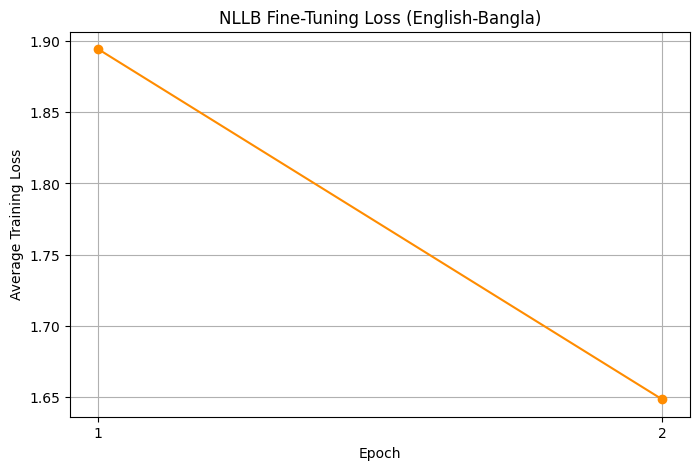

In [ ]:
# Plot the NLLB loss curve

import matplotlib.pyplot as plt

# We only have per-epoch averages (2 points) — that's expected, our print statements were per-batch, not saved per-batch
plt.figure(figsize=(8, 5))
plt.plot([1, 2], nllb_loss_history, marker='o', color='darkorange')
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("NLLB Fine-Tuning Loss (English-Bangla)")
plt.xticks([1, 2])
plt.grid(True)
plt.savefig(f"{PROJECT_DIR}/nllb_loss_curve.png")
plt.show()

In [ ]:
# Generate translations for the same 5 test sentences (for direct comparison to my from-scratch model)
def translate_nllb(sentence, model, tokenizer, device, max_len=80):
    model.eval()
    tokenizer.src_lang = "eng_Latn"
    inputs = tokenizer(sentence, return_tensors="pt").to(device)

    with torch.no_grad():
        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.convert_tokens_to_ids("ben_Beng"),
            max_length=max_len
        )
    return tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

test_sentences = [
    "Hello, how are you?",
    "I want to learn machine translation.",
    "This is a difficult project.",
    "The weather is nice today.",
    "Can you help me with this?"
]

for s in test_sentences:
    print(f"EN: {s}")
    print(f"BN: {translate_nllb(s, nllb_model, nllb_tokenizer, device)}")
    print()

EN: Hello, how are you?
BN: হ্যালো, কেমন আছ তুমি?

EN: I want to learn machine translation.
BN: আমি মেশিন অনুবাদ শিখতে চাই।

EN: This is a difficult project.
BN: এটা একটা কঠিন প্রকল্প।

EN: The weather is nice today.
BN: আজ আবহাওয়া ভালো।

EN: Can you help me with this?
BN: তুমি কি আমাকে সাহায্য করতে পারবে?



In [ ]:
# the formal BLEU number

import sacrebleu

references_nllb = []
hypotheses_nllb = []

for i in range(len(dataset["test"])):
    ex = dataset["test"][i]["translation"]
    en_text = ex["en"]
    bn_reference = ex["bn"]
    bn_hypothesis = translate_nllb(en_text, nllb_model, nllb_tokenizer, device)

    references_nllb.append(bn_reference)
    hypotheses_nllb.append(bn_hypothesis)

    if (i + 1) % 500 == 0:
        print(f"Translated {i + 1}/{len(dataset['test'])}...")

bleu_nllb = sacrebleu.corpus_bleu(hypotheses_nllb, [references_nllb])
print(f"\nFinal BLEU score (NLLB fine-tuned): {bleu_nllb.score:.2f}")

Translated 500/2000...
Translated 1000/2000...
Translated 1500/2000...
Translated 2000/2000...

Final BLEU score (NLLB fine-tuned): 9.23
